In [1]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# Notebook 1: Exploratory Data Analysis (EDA)
# ============================================================
# This notebook covers:
# - Dataset structure overview
# - Class distribution analysis
# - Sample image visualization
# - Image resolution consistency check
# - Pixel intensity distribution
# ============================================================

# Import Libraries

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [13]:
# Define paths
BASE_DIR = "../data"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Class names
CLASSES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

print(f"Train path : {TRAIN_DIR}")
print(f"Valid path : {VALID_DIR}")
print(f"Test  path : {TEST_DIR}")
print(f"Classes    : {CLASSES}")

Train path : ../data\train
Valid path : ../data\valid
Test  path : ../data\test
Classes    : ['glioma', 'meningioma', 'no_tumor', 'pituitary']


# Count Images Per Class

In [21]:
def count_images(directory, classes):
    counts = {}
    for cls in classes:
        path = os.path.join(directory, cls)
        if os.path.exists(path):
            counts[cls] = len([
                f for f in os.listdir(path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
        else:
            counts[cls] = 0
    return counts

train_counts = count_images(TRAIN_DIR, CLASSES)
valid_counts  = count_images(VALID_DIR, CLASSES)
test_counts   = count_images(TEST_DIR, CLASSES)

# Summary table
df_counts = pd.DataFrame({
    'Class'     : CLASSES,
    'Train'     : [train_counts[c] for c in CLASSES],
    'Validation': [valid_counts[c]  for c in CLASSES],
    'Test'      : [test_counts[c]   for c in CLASSES],
})
df_counts['Total'] = df_counts['Train'] + df_counts['Validation'] + df_counts['Test']

print("=" * 50)
print("       DATASET IMAGE COUNT SUMMARY")
print("=" * 50)
print(df_counts.to_string(index=False))
print("=" * 50)
print(f"TOTAL IMAGES : {df_counts['Total'].sum()}")
print(f"TRAIN        : {df_counts['Train'].sum()}")
print(f"VALIDATION   : {df_counts['Validation'].sum()}")
print(f"TEST         : {df_counts['Test'].sum()}")

       DATASET IMAGE COUNT SUMMARY
     Class  Train  Validation  Test  Total
    glioma    564         161    80    805
meningioma    358         124    63    545
  no_tumor    335          99    49    483
 pituitary    438         118    54    610
TOTAL IMAGES : 2443
TRAIN        : 1695
VALIDATION   : 502
TEST         : 246


# Class Distribution Bar Chart

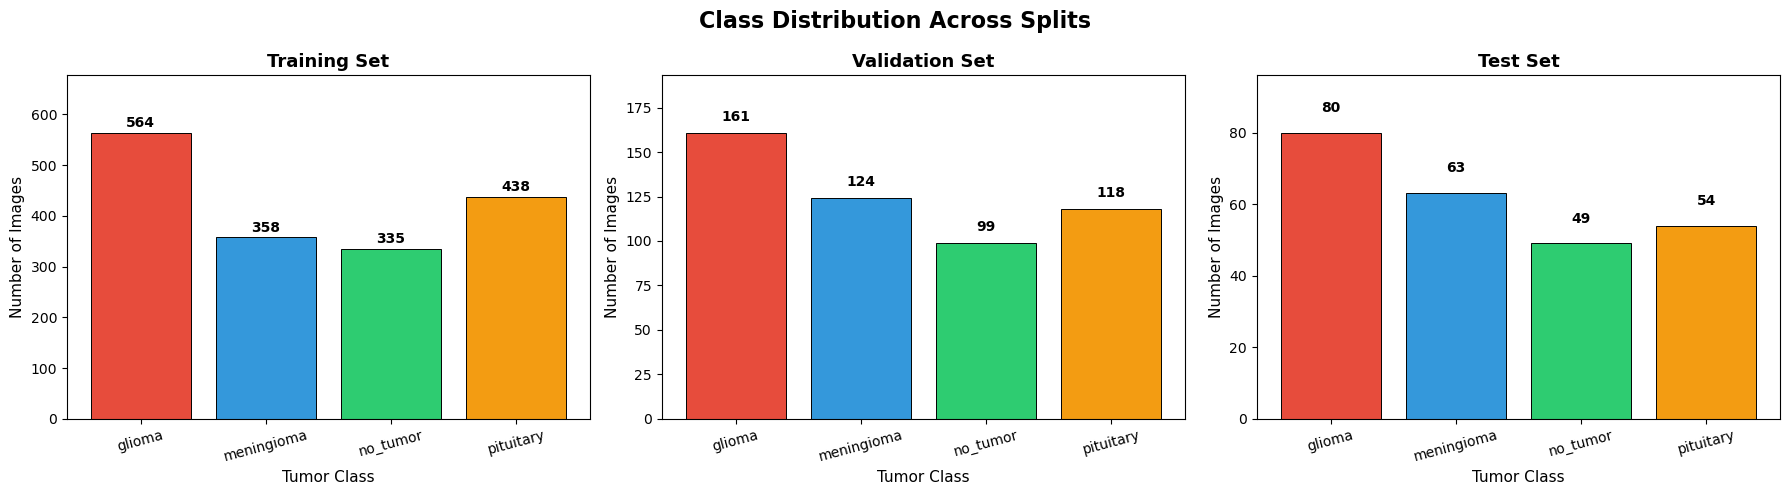

 Class distribution chart saved


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Class Distribution Across Splits', fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
splits = [
    ('Training Set',   train_counts),
    ('Validation Set', valid_counts),
    ('Test Set',       test_counts),
]

for ax, (title, counts) in zip(axes, splits):
    bars = ax.bar(CLASSES, [counts[c] for c in CLASSES], color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Tumor Class', fontsize=11)
    ax.set_ylabel('Number of Images', fontsize=11)
    ax.set_ylim(0, max(counts.values()) * 1.2)
    for bar, cls in zip(bars, CLASSES):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                str(counts[cls]),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Class distribution chart saved")

# Pie Chart (Train Split)

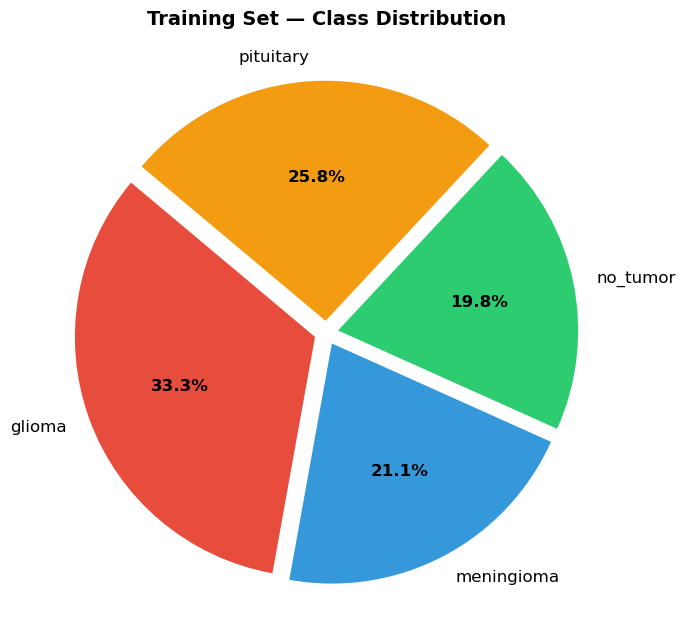

Pie chart saved


In [27]:
fig, ax = plt.subplots(figsize=(7, 7))

values = [train_counts[c] for c in CLASSES]
explode = [0.05] * 4

wedges, texts, autotexts = ax.pie(
    values,
    labels=CLASSES,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=140,
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')

ax.set_title('Training Set — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/class_distribution_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print("Pie chart saved")

# Sample Images Grid (5 per class)

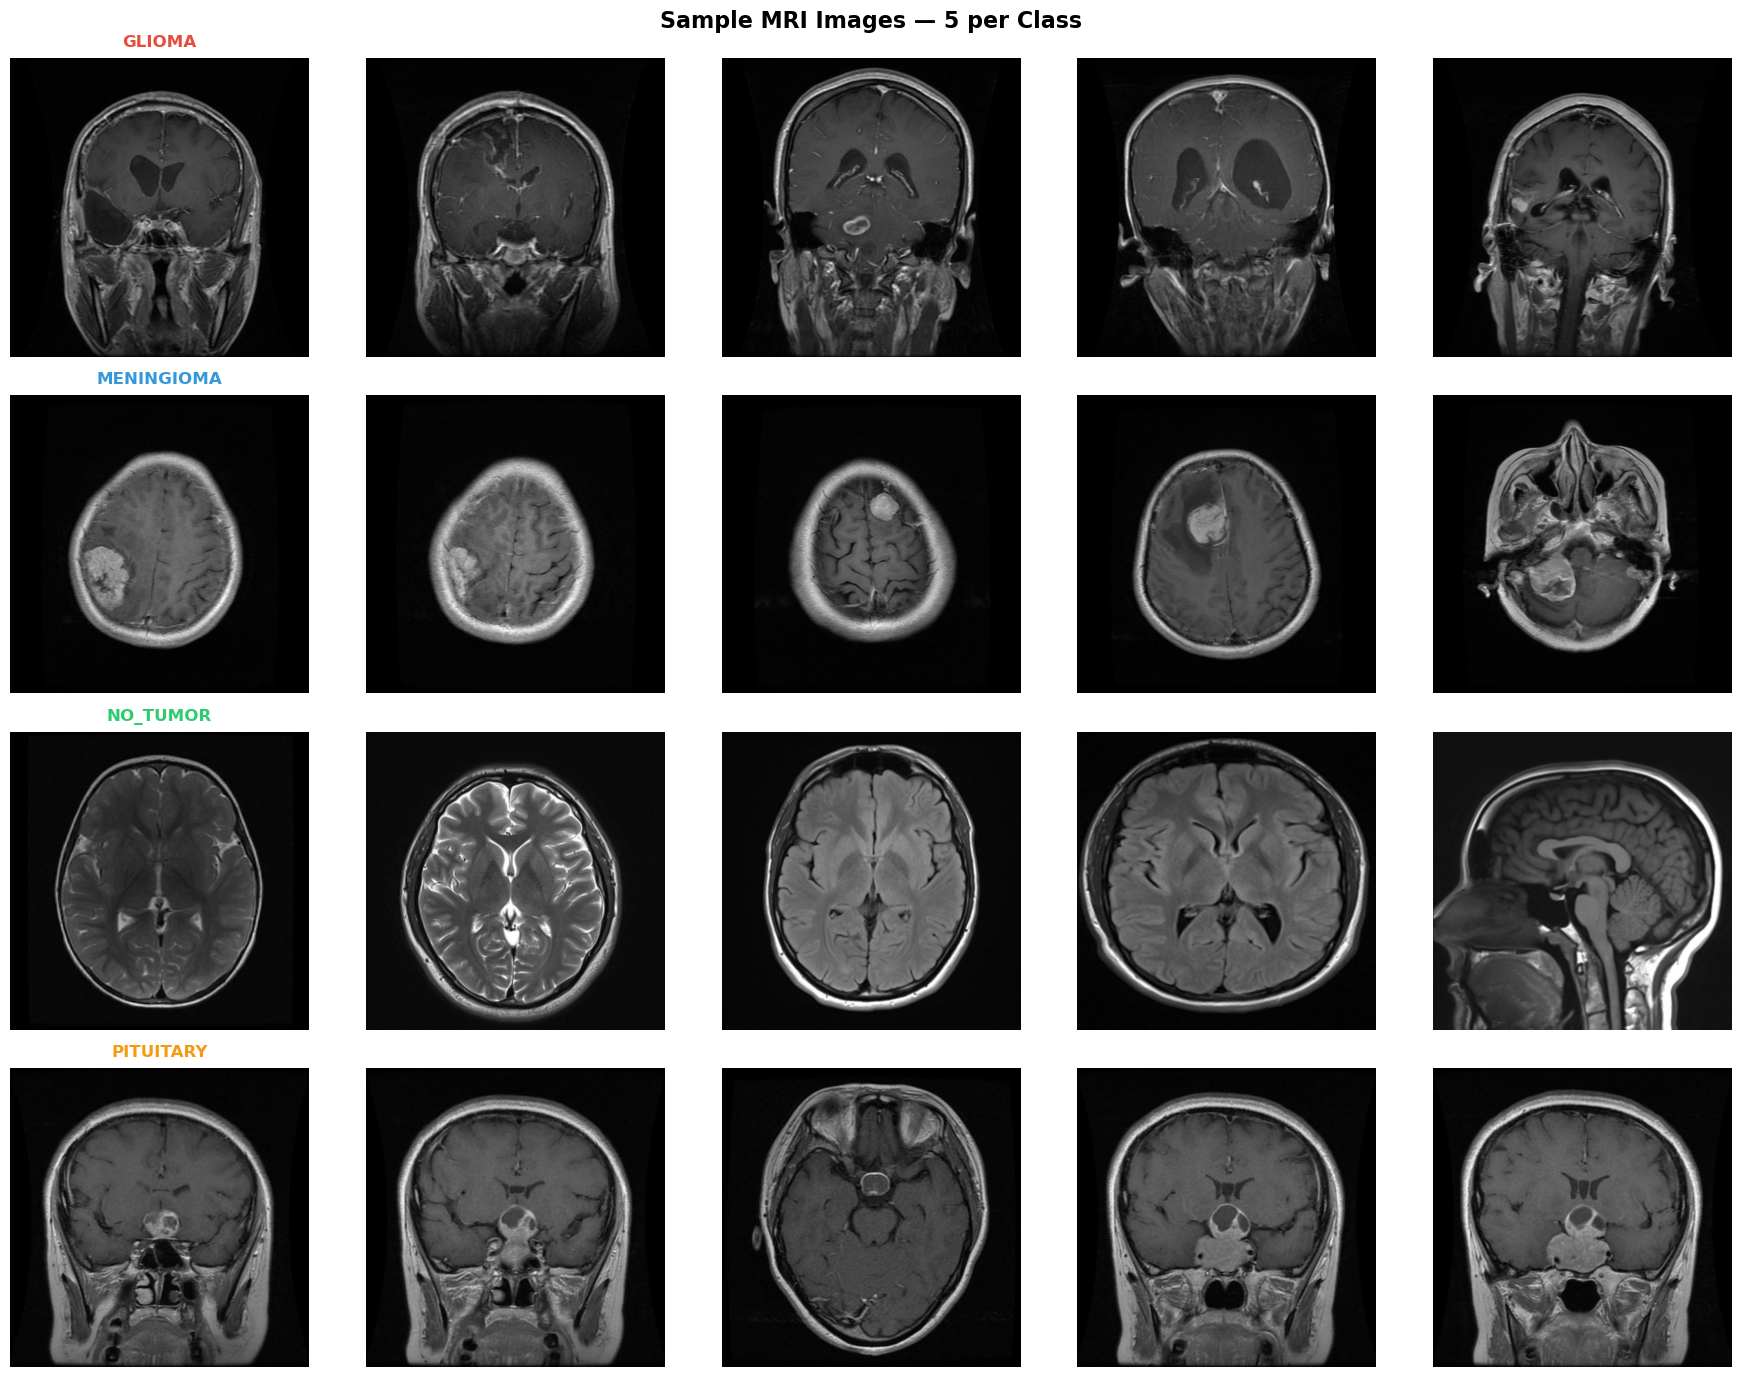

 Sample images grid saved


In [30]:
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
fig.suptitle('Sample MRI Images — 5 per Class', fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:5]

    for col, img_file in enumerate(images):
        img_path = os.path.join(cls_path, img_file)
        img      = mpimg.imread(img_path)
        axes[row, col].imshow(img, cmap='gray' if len(img.shape) == 2 else None)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f'{cls.upper()}', fontsize=12,
                                      fontweight='bold', color=colors[row], pad=8)

plt.tight_layout()
plt.savefig('../data/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Sample images grid saved")

# Image Resolution Check

In [33]:
print("Checking image resolutions in training set...\n")

resolution_data = []

for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:50]  # sample 50

    for img_file in images:
        img_path = os.path.join(cls_path, img_file)
        with Image.open(img_path) as img:
            w, h = img.size
            mode = img.mode
            resolution_data.append({
                'class' : cls,
                'width' : w,
                'height': h,
                'mode'  : mode
            })

df_res = pd.DataFrame(resolution_data)

print("Resolution Summary per Class:")
print("-" * 50)
print(df_res.groupby('class')[['width', 'height']].describe().round(1))
print("\nImage Modes (color channels):")
print(df_res['mode'].value_counts())
print("\n  All images will be resized to 224x224 during preprocessing")

Checking image resolutions in training set...

Resolution Summary per Class:
--------------------------------------------------
           width                                                height         \
           count   mean  std    min    25%    50%    75%    max  count   mean   
class                                                                           
glioma      50.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   50.0  640.0   
meningioma  50.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   50.0  640.0   
no_tumor    50.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   50.0  640.0   
pituitary   50.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   50.0  640.0   

                                                    
            std    min    25%    50%    75%    max  
class                                               
glioma      0.0  640.0  640.0  640.0  640.0  640.0  
meningioma  0.0  640.0  640.0  640.0  640.0  640.0  
no_tumor    0.0  640.0  640.0  640.0  6

# Pixel Intensity Distribution

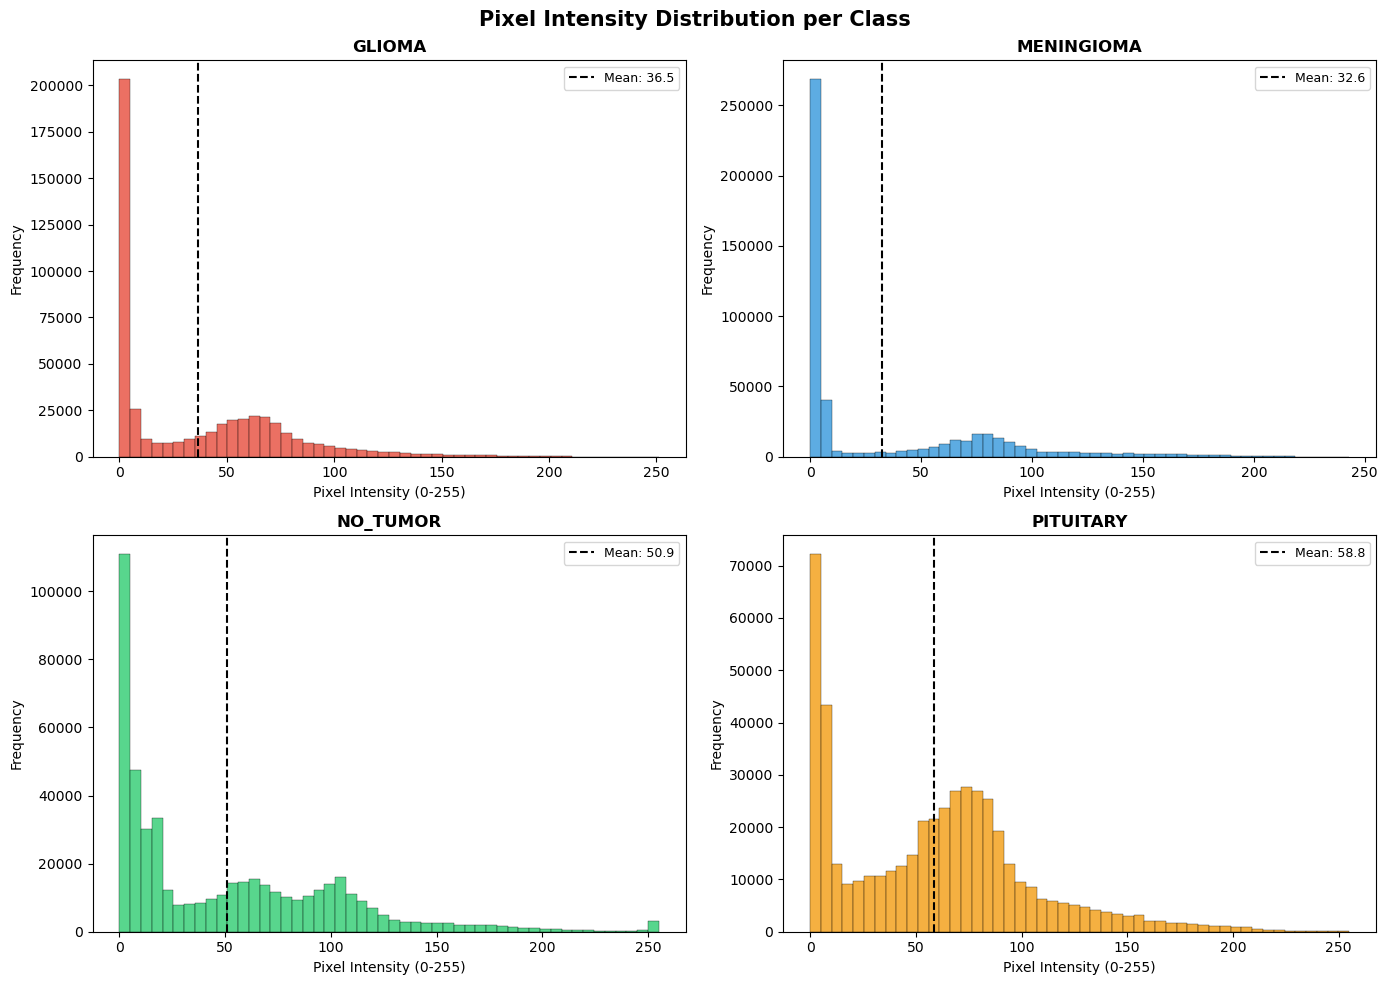

 Pixel intensity distribution saved


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pixel Intensity Distribution per Class', fontsize=15, fontweight='bold')

for ax, cls, color in zip(axes.flatten(), CLASSES, colors):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:30]

    all_pixels = []
    for img_file in images:
        img_path = os.path.join(cls_path, img_file)
        img      = Image.open(img_path).convert('L')  # grayscale
        img      = img.resize((128, 128))
        all_pixels.extend(np.array(img).flatten().tolist())

    ax.hist(all_pixels, bins=50, color=color, alpha=0.8, edgecolor='black', linewidth=0.3)
    ax.set_title(f'{cls.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel Intensity (0-255)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.axvline(np.mean(all_pixels), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean: {np.mean(all_pixels):.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/pixel_intensity.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Pixel intensity distribution saved")

# EDA Summary

In [39]:
print("=" * 55)
print("         EDA SUMMARY — BRAIN TUMOR MRI DATASET")
print("=" * 55)
print(f"  Total Classes     : {len(CLASSES)} → {CLASSES}")
print(f"  Total Images      : {df_counts['Total'].sum()}")
print(f"  Training Images   : {df_counts['Train'].sum()}")
print(f"  Validation Images : {df_counts['Validation'].sum()}")
print(f"  Test Images       : {df_counts['Test'].sum()}")
print("-" * 55)

# Class imbalance check
max_cls = max(train_counts, key=train_counts.get)
min_cls = min(train_counts, key=train_counts.get)
imbalance_ratio = train_counts[max_cls] / train_counts[min_cls]

print(f"  Most images class : {max_cls} ({train_counts[max_cls]} images)")
print(f"  Least images class: {min_cls} ({train_counts[min_cls]} images)")
print(f"  Imbalance ratio   : {imbalance_ratio:.2f}x")

if imbalance_ratio > 1.5:
    print("    Moderate class imbalance detected")
    print("      → Will handle via augmentation in Notebook 2")
else:
    print("   Classes are relatively balanced")

print("-" * 55)
print("  Next Step → Notebook 2: Preprocessing & Augmentation")
print("=" * 55)

         EDA SUMMARY — BRAIN TUMOR MRI DATASET
  Total Classes     : 4 → ['glioma', 'meningioma', 'no_tumor', 'pituitary']
  Total Images      : 2443
  Training Images   : 1695
  Validation Images : 502
  Test Images       : 246
-------------------------------------------------------
  Most images class : glioma (564 images)
  Least images class: no_tumor (335 images)
  Imbalance ratio   : 1.68x
    Moderate class imbalance detected
      → Will handle via augmentation in Notebook 2
-------------------------------------------------------
  Next Step → Notebook 2: Preprocessing & Augmentation
